In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

from astropy.io import fits

from scipy.optimize import curve_fit



In [2]:
def normalize_spectra_nb(bins,wavelength,flux):

    x_bin=np.zeros(len(bins)-1)
    y_bin=np.zeros(len(bins)-1)
    for i in range(len(bins)-1):
        idxup = wavelength>bins[i]
        idxdown= wavelength<bins[i+1]
        idx=idxup & idxdown
        y_bin[i]=flux[idx].max()
        x_bin[i]=wavelength[idx][np.argmax(flux[idx])]
    #divide by 6th deg polynomial

    return x_bin, y_bin

# Physical constants in SI units
h = 6.62607015e-34  # Planck constant [J·s]
c = 2.99792458e8    # Speed of light [m/s]
k = 1.380649e-23    # Boltzmann constant [J/K]

def black_body_lambda(wavelength_m, temperature_K, amplitude):
    """
    Compute the spectral radiance of a black body at a given temperature and wavelength.

    Parameters:
        wavelength_m (float or ndarray): Wavelength in meters.
        temperature_K (float): Temperature in Kelvin.

    Returns:
        float or ndarray: Spectral radiance in W·sr⁻¹·m⁻³
    """
    return amplitude * (2.0 * h * c**2) / (wavelength_m**5) / (np.exp((h * c) / (wavelength_m * k * temperature_K)) - 1.0) / (wavelength_m * 1e-2)**2

In [3]:
n_bins = 40
overhead=1.0
bins=np.linspace(ss_mps.wavelength_lower_limit-overhead,ss_mps.wavelength_upper_limit+overhead,n_bins)

[wv, flux, x_bin, y_bin] = ss_mps.results['fits_spec']
x_bin, y_bin = normalize_spectra_nb(bins,wv,flux)
coeff = np.polyfit(x_bin, y_bin, 8)

popt, pcov = curve_fit(black_body_lambda, x_bin * 1e-10, y_bin, bounds=(0, [1e4, 1]))

plt.plot(wv, flux, color='#b6d7a8')
plt.plot(x_bin, y_bin, 'o', color='#ff9900')
plt.plot(wv, np.poly1d(coeff)(wv), ':',color='#ff9900', label='fit')
# plt.plot(wv, black_body_lambda(wv/1e10, *popt), color='#f1d7ff', label='black body')
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('MPS-ATLAS spectra, mu = 1.0')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/mps_hires_fit.png', dpi=300)
plt.show()



NameError: name 'ss_mps' is not defined

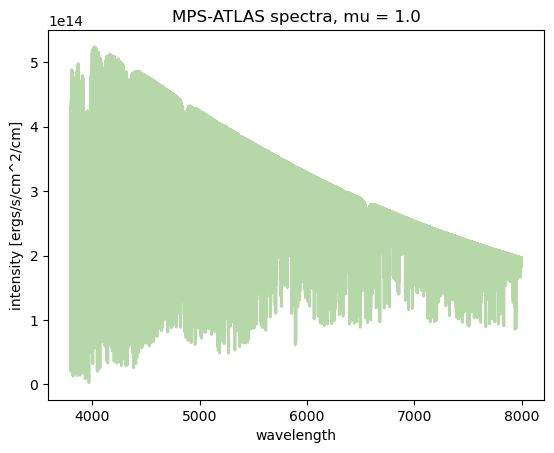

In [ ]:
[wv, flux, x_bin, y_bin] = ss_mps.results['fits_spec']

plt.plot(wv, flux, color='#b6d7a8')
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('MPS-ATLAS spectra, mu = 1.0')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/mps_hires_fit.png', dpi=300)
plt.show()

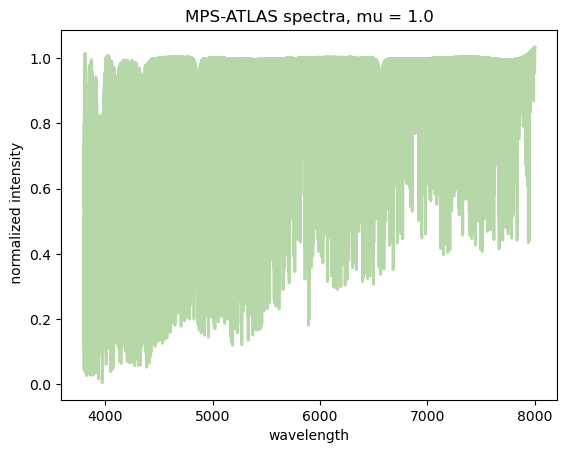

In [ ]:
plt.plot(wv, flux/np.poly1d(coeff)(wv), color='#b6d7a8')
plt.xlabel('wavelength')
plt.ylabel(' normalized intensity')
plt.title('MPS-ATLAS spectra, mu = 1.0')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/mps_hires_norm.png', dpi=300)


In [ ]:
data = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid.npy', allow_pickle=True).item()
data_2 = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/av_solar_ssd_200G_10_mu_angles_PHOENIX_high_res_grid.npy', allow_pickle=True).item()
data_ph = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix_mu/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-SPECINT-2011.fits')[0].data
data_low_res = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits')[0].data
wv_ph = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits')[0].data

In [ ]:
mu = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix_mu/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-SPECINT-2011.fits')[1].data
amu = 0.12

mu_low=np.max(mu[mu<amu]) #angles above and below the proj. angle of the grid
mu_upp=np.min(mu[mu>=amu])
idx_low=np.where(mu==mu_low)[0][0]
idx_upp=np.where(mu==mu_upp)[0][0]
dlp_ph = data_ph[idx_low]+(data_ph[idx_upp]-data_ph[idx_low])*(amu-mu_low)/(mu_upp-mu_low)

len(dlp_ph/data_ph[-1])

mu = np.linspace(0.1, 1, 10)


mu_low=np.max(mu[mu<amu]) #angles above and below the proj. angle of the grid
mu_upp=np.min(mu[mu>=amu])
idx_upp=np.where(mu==mu_upp)[0][0]
dlp_mps = data[str(mu_low)]['intensity']+(data[str(mu_upp)]['intensity']-data[str(mu_low)]['intensity'])*(amu-mu_low)/(mu_upp-mu_low)

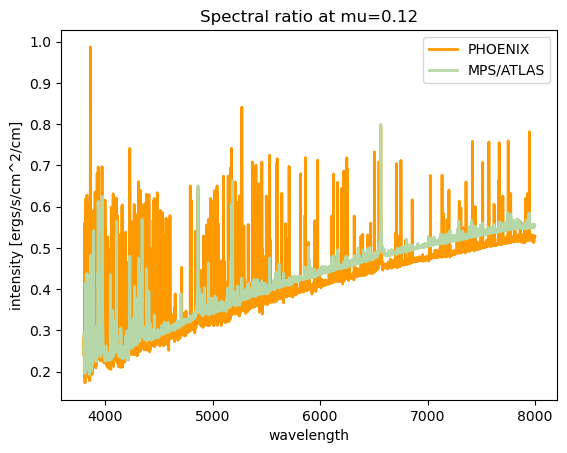

In [ ]:
plt.rcParams['font.size'] = 10

plt.plot(np.arange(3801,8000),(dlp_ph/data_ph[-1])[3301:7500] , color='#ff9900', label='PHOENIX') # erg/s/cm2/cm
plt.plot(data['1.0']['wav'], (dlp_mps) / (data['1.0']['intensity']), color='#C6D8AF', label='MPS/ATLAS') # erg/s/cm2/A
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('Spectral ratio at mu=0.12')
plt.legend()

plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/low_res_ratio_mu_0.12.png', dpi=300)
plt.show()

In [ ]:
np.shape(ss_mps.results['CCF'][1:])

(40, 145)

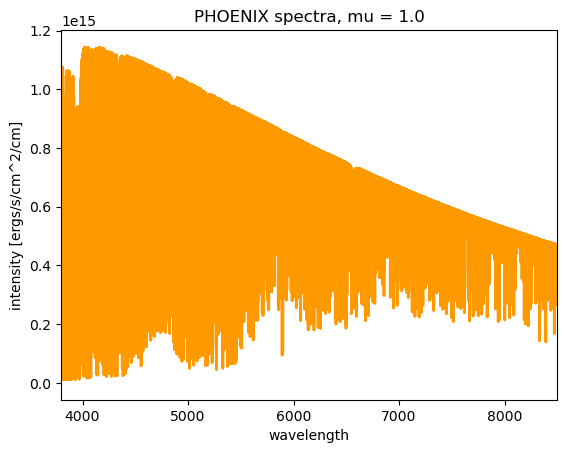

In [ ]:
plt.plot(wv_ph, data_low_res, color='#ff9900')
plt.xlim(3800,8500)
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('PHOENIX spectra, mu = 1.0')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/phoenix_hires.png', dpi=300)

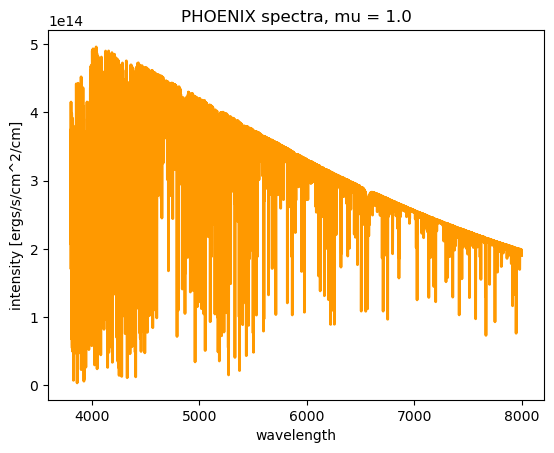

In [ ]:
plt.plot(np.arange(3801,8000), data_ph[-1][3301:7500], color='#ff9900') # erg/s/cm2/cm
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('PHOENIX spectra, mu = 1.0')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/phoenix_low_res.png', dpi=300)

[7.88719963e+14 7.88512514e+14 7.88305175e+14 ... 3.74881153e+14
 3.74834281e+14 3.74787421e+14]


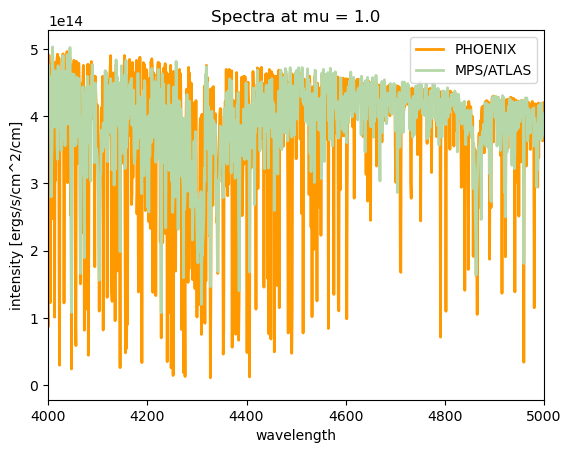

In [ ]:
f = 2.99792458e10 / (data['1.0']['wav'] / 1e8)
print(f)
plt.plot(np.arange(3801,8000), data_ph[-1][3301:7500], color='#ff9900', label='PHOENIX') # erg/s/cm2/cm
plt.plot(data['1.0']['wav'], data['1.0']['intensity'] / ( 1e-8 * data['1.0']['wav'])**2 * 2.99792458e10, color='#b6d7a8', label='MPS/ATLAS') # erg/s/cm2/A
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.title('Spectra at mu = 1.0')
plt.legend()
wv_low = 4000
plt.xlim(wv_low,wv_low+1000)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/low_res_{}-{}.png'.format(wv_low,wv_low+1000), dpi=300)
plt.show()




In [ ]:
lamb= 6124
n_l = 10
idx = np.argwhere(np.abs(data['1.0']['wav']-lamb)<n_l)

In [ ]:
np.argmin(data_ph[-1][lamb-n_l-500:lamb+n_l-500]) + lamb-n_l

np.int64(6124)

In [ ]:
mu = np.fromiter(data_2.keys(), dtype=float)

flux = []
for mu_i in mu:
    flux.append(np.array(data_2[str(mu_i)]['intensity'] / ( 1e-8 * data_2[str(mu_i)]['wav']) * 4 * np.pi * 2.99792458e10))

    

In [ ]:
def air2vacuum(wv): #wv in angstroms
    wv=wv*1e-4 #A to micrometer
    a=0
    b1=5.792105e-2
    b2=1.67917e-3
    c1=238.0185
    c2=57.362

    n=1+a+b1/(c1-(1/wv**2))+b2/(c2-(1/wv**2))

    w=(wv*n)*1e4 #to Angstroms
    return w

print(air2vacuum((6122.193293	+6122.254515)/2))

6123.91857611426


In [ ]:
name_mps = 'av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid'
name_mps_fc = 'av_solar_faculae_200G_10_mu_angles_PHOENIX_low_res_specint_grid'
raw_mps = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps+'.npy', allow_pickle=True).item()
raw_mps_fc = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps_fc+'.npy', allow_pickle=True).item()


In [ ]:
# --- Step 1: Collect all wavelength arrays ---
all_wavelengths_1 = [v['wav'] for v in raw_mps.values()]
all_wavelengths_2 = [v['wav'] for v in raw_mps_fc.values()]
all_wavelengths = all_wavelengths_1 + all_wavelengths_2

# --- Step 2: Find the common wavelengths ---
common_wavelength = np.array(list(set(all_wavelengths[0]).intersection(*all_wavelengths[1:])))
common_wavelength.sort()  # Optional but nice

# --- Step 3: Filter both dictionaries ---
def filter_to_common(data_dict, common_wl):
    filtered = {}
    for mu, v in data_dict.items():
        wl = v['wav']
        inten = v['intensity']
        
        mask = np.isin(wl, common_wl)
        wl_common = wl[mask]
        inten_common = inten[mask]
        
        # Order according to common_wavelength
        order = np.argsort(np.searchsorted(common_wl, wl_common))
        final_wv = wl_common[order]
        inten_ordered = inten_common[order]
        
        filtered[mu] = {
            'wav': final_wv,
            'intensity': inten_ordered
        }
    return filtered

filtered_mps_ph = filter_to_common(raw_mps, common_wavelength)
filtered_mps_fc = filter_to_common(raw_mps_fc, common_wavelength)

np.save('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps+'_cleaned.npy',filtered_mps_ph, allow_pickle=True)
np.save('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps_fc+'_cleaned.npy',filtered_mps_fc, allow_pickle=True)



In [ ]:
raw_mps_cleaned = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps+'_cleaned.npy', allow_pickle=True).item()

raw_mps_fc_cleaned = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'+name_mps_fc+'_cleaned.npy', allow_pickle=True).item()

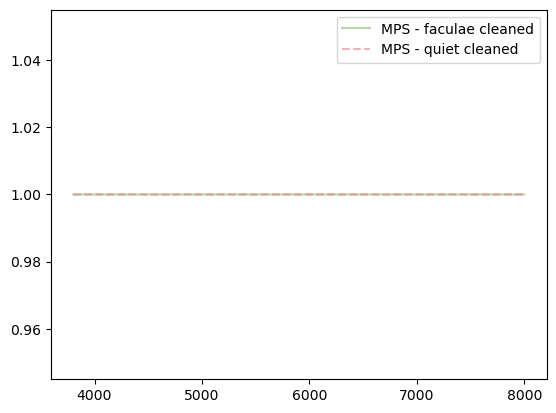

In [ ]:
plt.plot(raw_mps_fc_cleaned['1.0']['wav'][1:], np.diff(raw_mps_fc_cleaned['1.0']['wav']), label='MPS - faculae cleaned', color='#b6d7a8')
plt.plot(filtered_mps_ph['0.6']['wav'][1:], np.diff(filtered_mps_ph['1.0']['wav']),'--', label='MPS - quiet cleaned', color='#eb6565', alpha=0.5)


plt.legend()

In [ ]:
np.sum(raw_mps_cleaned['1.0']['wav'] - raw_mps_fc_cleaned['0.5']['wav'])

np.float64(0.0)

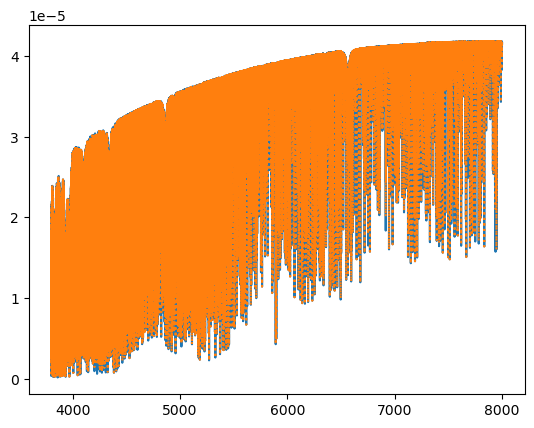

In [ ]:
mu = '1.0'
plt.plot(raw_mps[mu]['wav']*10, raw_mps[mu]['intensity'])
plt.plot(raw_mps_cleaned[mu]['wav'], raw_mps_cleaned[mu]['intensity'],':')



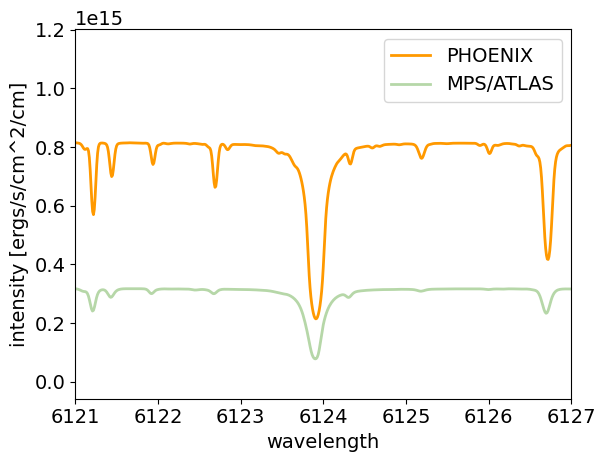

In [ ]:
plt.rcParams['font.size'] = 14

plt.plot(wv_ph, data_low_res, color='#ff9900', label='PHOENIX') # erg/s/cm2/cm
plt.plot(raw_mps_cleaned['1.0']['wav'],   (raw_mps_cleaned['1.0']['intensity'] / ( 1e-8 * raw_mps_cleaned['1.0']['wav'])**2 * 2.99792458e10), color='#b6d7a8', label='MPS/ATLAS') # erg/s/cm2/A
plt.xlabel('wavelength')
plt.ylabel('intensity [ergs/s/cm^2/cm]')
plt.legend()
plt.xlim(6121,6127)
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/high_res_FeI.png', dpi=300)

In [ ]:
plt.plot(ss_mps.results['CCF'][0],ss_mps.results['ccf_ph'], color='#b6d7a8',label='MPS-ATLAS, conv=0')
# plt.plot(ss_mps.results['CCF'][0],ss_mps_blue.results['ccf_ph'],':', color='#eb6565',label='MPS-ATLAS, conv=1')
# plt.plot(ss_phoenix.results['CCF'][0],ss_phoenix.results['ccf_ph'], color='#f1d7ff', label='PHOENIX, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_phoenix_blue.results['ccf_ph'], ':',color='#ff9900', label='PHOENIX, conv=1')
plt.legend()
plt.title('Quiet')
plt.xlabel('RV [m/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/ccf_quiet_{}.png'.format(spec_line), dpi=300)

print(ss_mps.results['CCF'][0][np.argmax(ss_mps.results['ccf_ph'])])
# print(ss_phoenix.results['CCF'][0][np.argmax(ss_phoenix.results['ccf_ph'])])



KeyError: 'ccf_ph'

-1000.0
-500.0


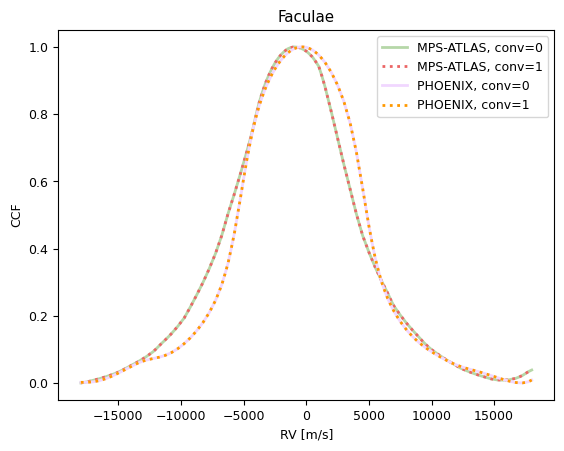

In [ ]:
plt.plot(ss_mps.results['CCF'][0],ss_mps.results['ccf_fc'], color='#b6d7a8',label='MPS-ATLAS, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_mps_blue.results['ccf_fc'], ':', color='#eb6565',label='MPS-ATLAS, conv=1')
plt.plot(ss_mps.results['CCF'][0],ss_phoenix.results['ccf_fc'], color='#f1d7ff', label='PHOENIX, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_phoenix_blue.results['ccf_fc'], ':',color='#ff9900', label='PHOENIX, conv=1')
plt.legend()
plt.title('Faculae')
plt.xlabel('RV [m/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/ccf_faculae_{}.png'.format(spec_line), dpi=300)


print(ss_mps.results['CCF'][0][np.argmax(ss_mps.results['ccf_fc'])])
print(ss_phoenix.results['CCF'][0][np.argmax(ss_phoenix.results['ccf_fc'])])

In [ ]:
ss_phoenix.results['amu']



array([1.        , 0.99965154, 0.99860641, 0.99686533, 0.99442953,
       0.99130068, 0.98748099, 0.9829731 , 0.97778016, 0.97190579,
       0.96535409, 0.95812961, 0.9502374 , 0.94168295, 0.93247223,
       0.92261165, 0.91210809, 0.90096887, 0.88920174, 0.87681492,
       0.86381703, 0.85021714, 0.83602471, 0.82124964, 0.80590223,
       0.78999318, 0.77353356, 0.75653486, 0.73900892, 0.72096795,
       0.70242452, 0.68339156, 0.66388234, 0.64391045, 0.6234898 ,
       0.60263464, 0.58135949, 0.55967917, 0.53760882, 0.51516379,
       0.49235973, 0.46921255, 0.44573836, 0.42195352, 0.39787463,
       0.37351844, 0.34890195, 0.3240423 , 0.29895682, 0.27366299,
       0.24817844, 0.22252093, 0.19670835, 0.17075867, 0.14468999,
       0.11852048, 0.09226836, 0.06595194, 0.03958956, 0.01319959])

0.0
0.0


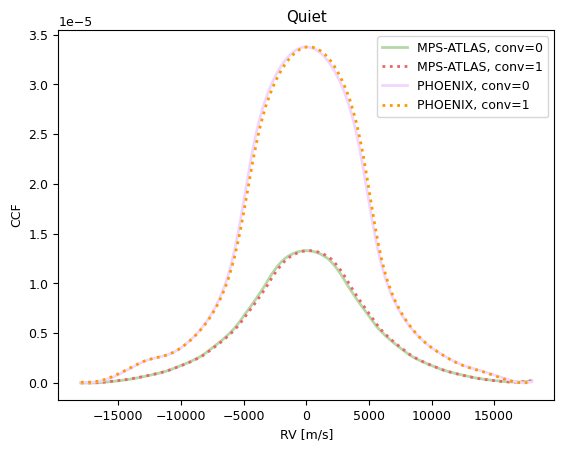

In [ ]:
plt.plot(ss_mps.results['CCF'][0],ss_mps.results['ccf_ph_g'][7830], color='#b6d7a8',label='MPS-ATLAS, conv=0')
plt.plot(ss_mps_blue.results['CCF'][0],ss_mps_blue.results['ccf_ph_g'][7830], ':', color='#eb6565',label='MPS-ATLAS, conv=1')

plt.plot(ss_mps.results['CCF'][0],ss_phoenix.results['ccf_ph_g'][7830], color='#f1d7ff', label='PHOENIX, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_phoenix_blue.results['ccf_ph_g'][7830], ':',color='#ff9900', label='PHOENIX, conv=1')
plt.legend()
plt.title('Quiet')
plt.xlabel('RV [m/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/ccf_quiet_mu_0.12_{}.png'.format(spec_line), dpi=300)

print(ss_mps.results['CCF'][0][np.argmax(ss_mps.results['ccf_ph_g'][7830])])
print(ss_phoenix.results['CCF'][0][np.argmax(ss_phoenix.results['ccf_ph_g'][7830])])

0.0
0.0


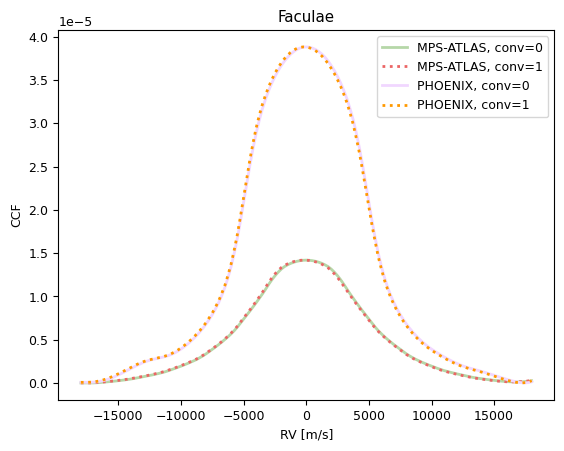

In [ ]:
plt.plot(ss_mps.results['CCF'][0],ss_mps.results['ccf_fc_g'][7830], color='#b6d7a8',label='MPS-ATLAS, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_mps_blue.results['ccf_fc_g'][7830],':', color='#eb6565',label='MPS-ATLAS, conv=1')

plt.plot(ss_mps.results['CCF'][0],ss_phoenix.results['ccf_fc_g'][7830], color='#f1d7ff', label='PHOENIX, conv=0')
plt.plot(ss_mps.results['CCF'][0],ss_phoenix_blue.results['ccf_fc_g'][7830], ':',color='#ff9900', label='PHOENIX, conv=1')
plt.legend()
plt.title('Faculae')
plt.xlabel('RV [m/s]')
plt.ylabel('CCF')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/ccf_faculae_mu_0.12_{}.png'.format(spec_line), dpi=300)

print(ss_mps.results['CCF'][0][np.argmax(ss_mps.results['ccf_fc_g'][7830])])
print(ss_phoenix.results['CCF'][0][np.argmax(ss_phoenix.results['ccf_fc_g'][7830])])

In [ ]:
plt.rcParams['font.size'] = 18

def update(frame, ax, fig, lags, scalar_map, t, rv_sim, CCF_p, RV, BIS, raw_xbis, raw_ybis, lc, path_grid):
    ax[1,0].cla()
    ax[1,1].cla()
    lag = lags[frame]

    color_val = scalar_map.to_rgba(rv_sim[lag])
    
    #plot RVs
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,2].plot(t[i],rv_sim[i], color=color_val,marker='.', markersize=12)
    ax[0,2].set_xlim(t.min(),t.max())
    ax[0,2].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[0,2].plot(t[:lag],rv_sim[:lag],color='gray', alpha=0.2, linewidth= 1)
    
    #plot CCF
    ax[1,0].plot(RV[:],CCF_p[lag], color=color_val,alpha=0.9)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,0].plot(RV[:],CCF_p[i], color=color_val,alpha=0.1)


    #plot BIS (mean diff)
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,2].plot(t[i],BIS[i], color=color_val,marker='.', linestyle='None', markersize=12)
    ax[1,2].plot(t[:lag],BIS[:lag],color='gray', alpha=0.2, linewidth= 1)

    #plot BIS
    ax[1,1].plot(raw_xbis[lag] - (np.max(raw_xbis[lag]) + np.min(raw_xbis[lag])) / 2,raw_ybis[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1,1].plot(raw_xbis[i] - (np.max(raw_xbis[i]) + np.min(raw_xbis[i])) / 2,raw_ybis[i], color=color_val,alpha=0.1)
    ax[1,1].set_xlim(-50, 50)


    #plot flux intensity
    for i in range(len(t)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0,1].plot(t[i],lc[i], color=color_val,marker='.', markersize=12)
    ax[0,1].set_xlim(t.min(),t.max())
    ax[0,1].plot(t[:lag],lc[:lag],color='gray', alpha=0.2, linewidth= 1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))

    
    color_dict = { 0:'#CA6702', 1:'#9B2226', 2:'#EE9B00', 3:'#0A9396'}
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    vec_grid=np.load(path_grid+'vec_gridt{:.4f}.npy'.format(t[lag]))
    typ=np.load(path_grid+'typt{:.4f}.npy'.format(t[lag]))
    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[0,0].scatter(vec_grid[:,1],vec_grid[:,2], color=[ color_dict[np.argmax(i)] for i in typ ],s=50, alpha=0.8)
    #ax[0,0].plot(x,h,'k')
    
    ax[1,0].set_ylabel('CCF power')
    ax[1,0].set_xlabel('RV (m/s)')
    ax[1,0].set_ylim(CCF_p.min()-np.abs(CCF_p.min())/10,CCF_p.max()+np.abs(CCF_p.max())/10)
    ax[0,2].set_ylabel('RV (m/s)')
    ax[0,2].set_xlabel('t (d)')
    ax[0,1].set_ylabel('f')
    ax[0,1].set_xlabel('t (d)')
    ax[1,2].set_ylabel('BIS span')
    ax[1,2].set_xlabel('t (D)')
    ax[1,1].set_xlabel('RV (m/S)')
    ax[1,1].set_ylabel('BIS')

    ax[0,0].locator_params(axis='y',nbins=5)
    ax[1,0].locator_params(axis='x',nbins=5)

    ax[0,1].ticklabel_format(axis='both', style='sci')
    ax[1,0].ticklabel_format(axis='both', style='sci')

    ax[0,0].tick_params(grid_alpha=0.7)
    ax[0,1].tick_params(grid_alpha=0.7)
    ax[0,2].tick_params(grid_alpha=0.7)
    ax[1,0].tick_params(grid_alpha=0.7)
    ax[1,1].tick_params(grid_alpha=0.7)
    ax[1,2].tick_params(grid_alpha=0.7)

    fig.tight_layout()


def retrieve_observable(ss, t, pathdata, path_grid, output):
    """
    Load and save the #TODO

    Params:
            -ss: starsim object
            -t: timeframe
    
    """

    rv_sim=ss.results['rv']
    CCF=ss.results['CCF'][1:]
    RV=ss.results['CCF'][0]
    lc = ss.results['lc']
    BIS = ss.results['bis']
    raw_xbis = ss.results['raw_xbis']
    raw_ybis = ss.results['raw_ybis']



    '''
    Generate an animated GIF
    '''

    CCF_p =CCF[:] -np.mean(CCF,axis=0)

    lags = np.arange(len(t))


    # Normalize the continuous variable to map it to the range [0, 1] for the colormap
    norm = Normalize(vmin=-np.max((np.abs(rv_sim))), vmax=np.max((np.abs(rv_sim))))
    List = ['#104f5c', '#2c6570', '#477b83', '#639295', '#84a8a5', '#c7b7a0', '#e49a77', '#e5845f', '#de714d', '#d3603e', '#c65031']

    colormap = get_continuous_cmap(List)
    scalar_map = ScalarMappable(norm=norm, cmap=colormap)

    fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30/1.5 + 2, 20/1.5))

    # Create an animation
    ani = FuncAnimation(fig, partial(update, ax=ax, fig=fig, lags=lags, scalar_map=scalar_map, t=t, rv_sim=rv_sim, CCF_p=CCF_p, RV=RV, BIS=BIS, raw_xbis=raw_xbis, raw_ybis=raw_ybis, lc=lc, path_grid=path_grid), frames=len(lags), repeat=False)

    # Save the animation as a video
    writer = FFMpegWriter(fps=3, metadata=dict(artist='Me'), bitrate=2400)

    
    ani.save(pathdata+output+'.gif', writer=writer)

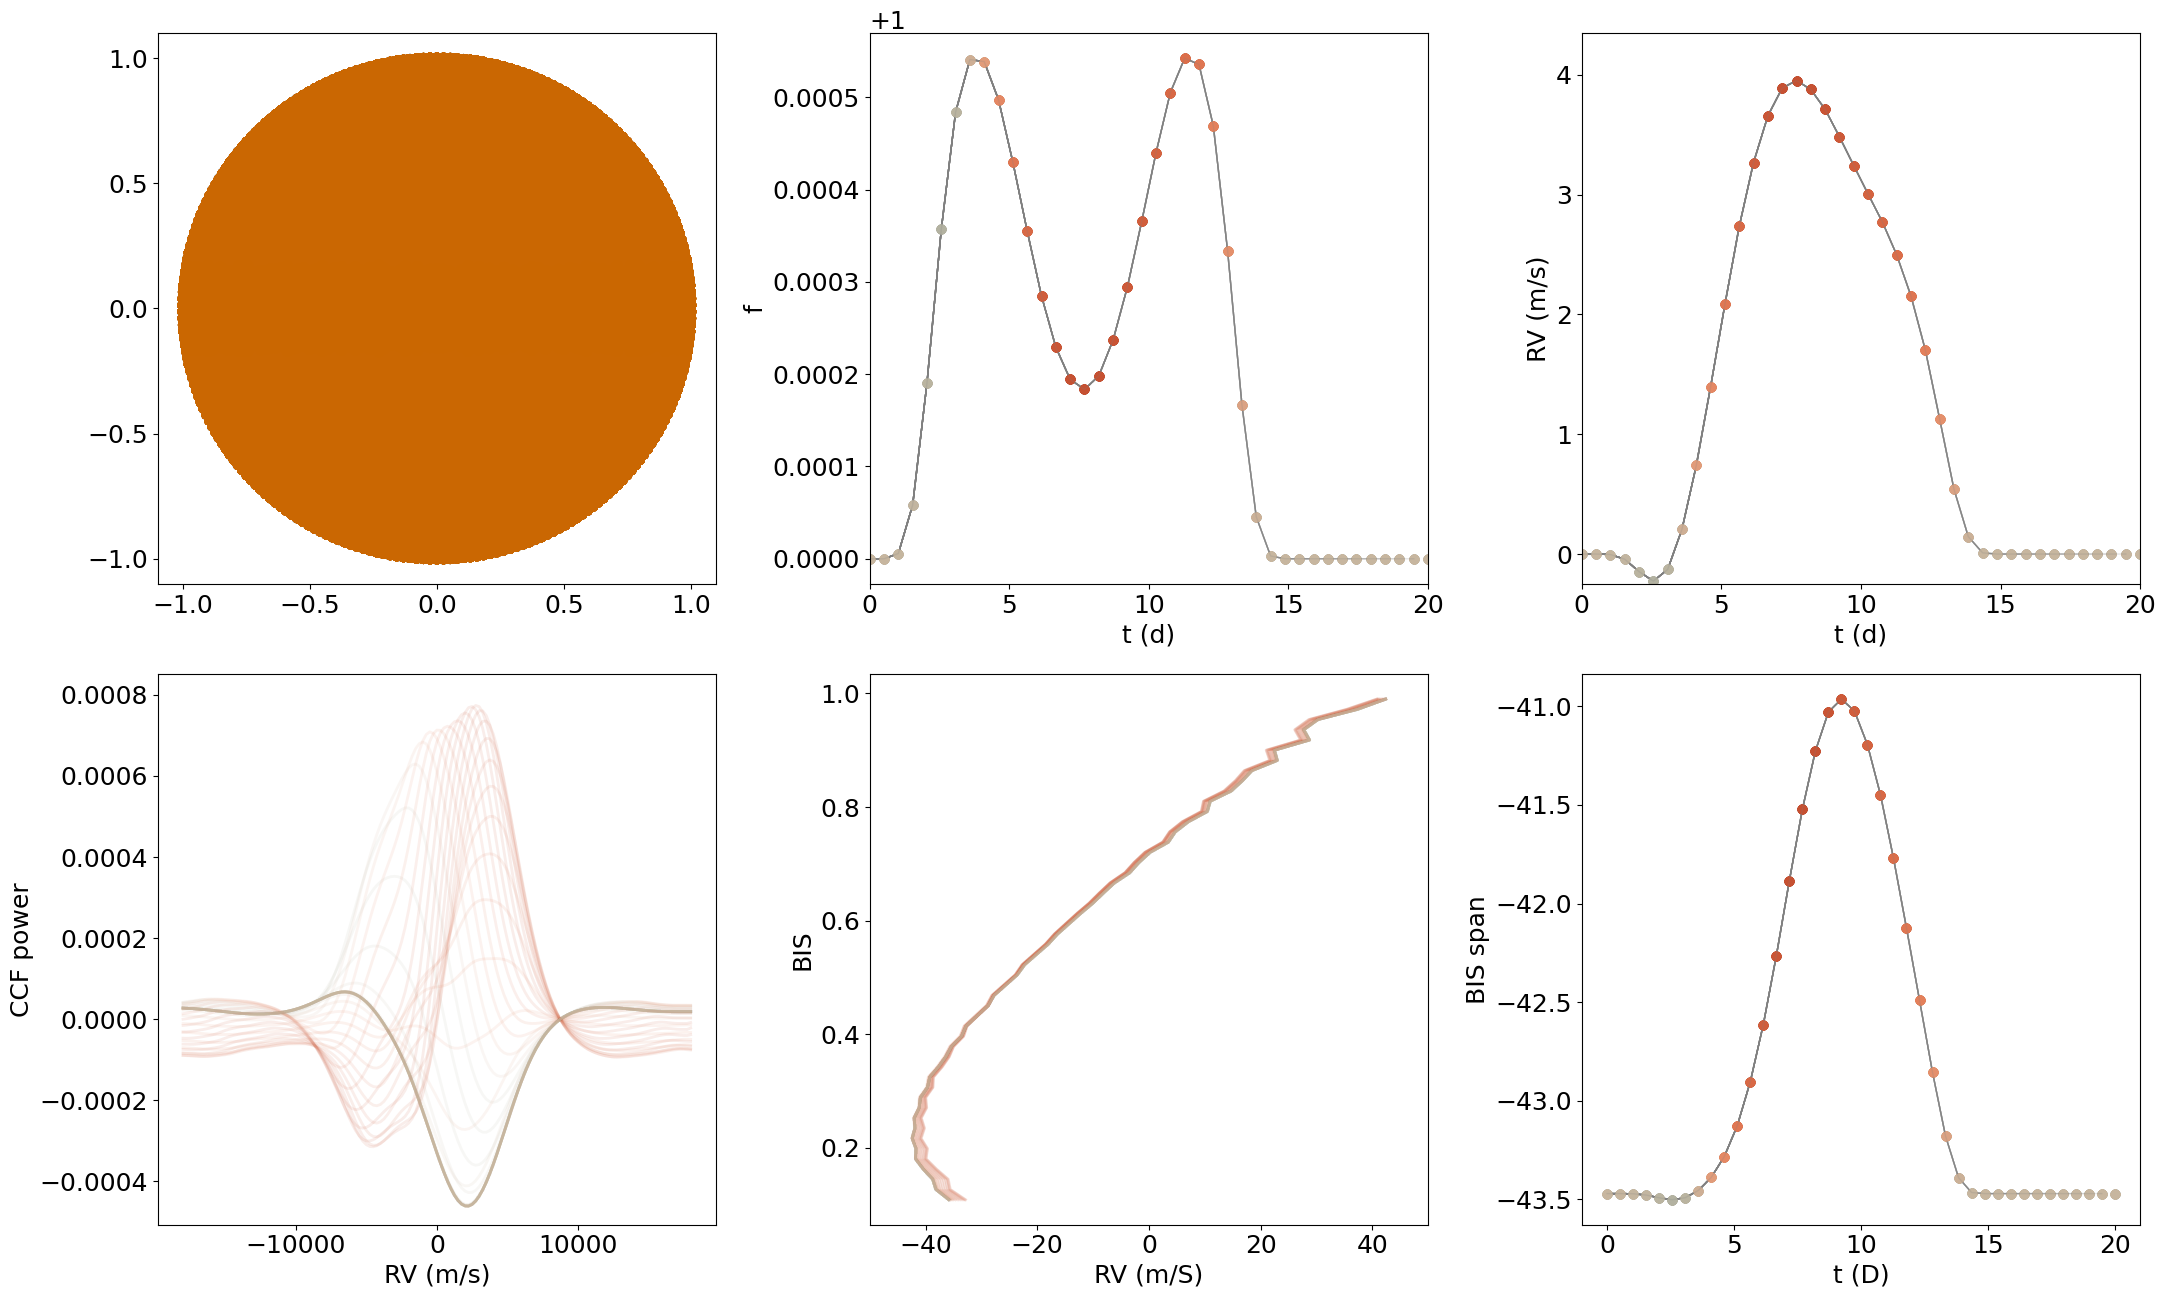

In [ ]:
output = 'fc_mps_{}'.format(spec_line)
retrieve_observable(ss_mps, t, pathdata, path_grid, output)

In [ ]:
# output = 'fc_mps_blue_{}'.format(spec_line)
# retrieve_observable(ss_mps_blue, t, pathdata, path_grid, output)

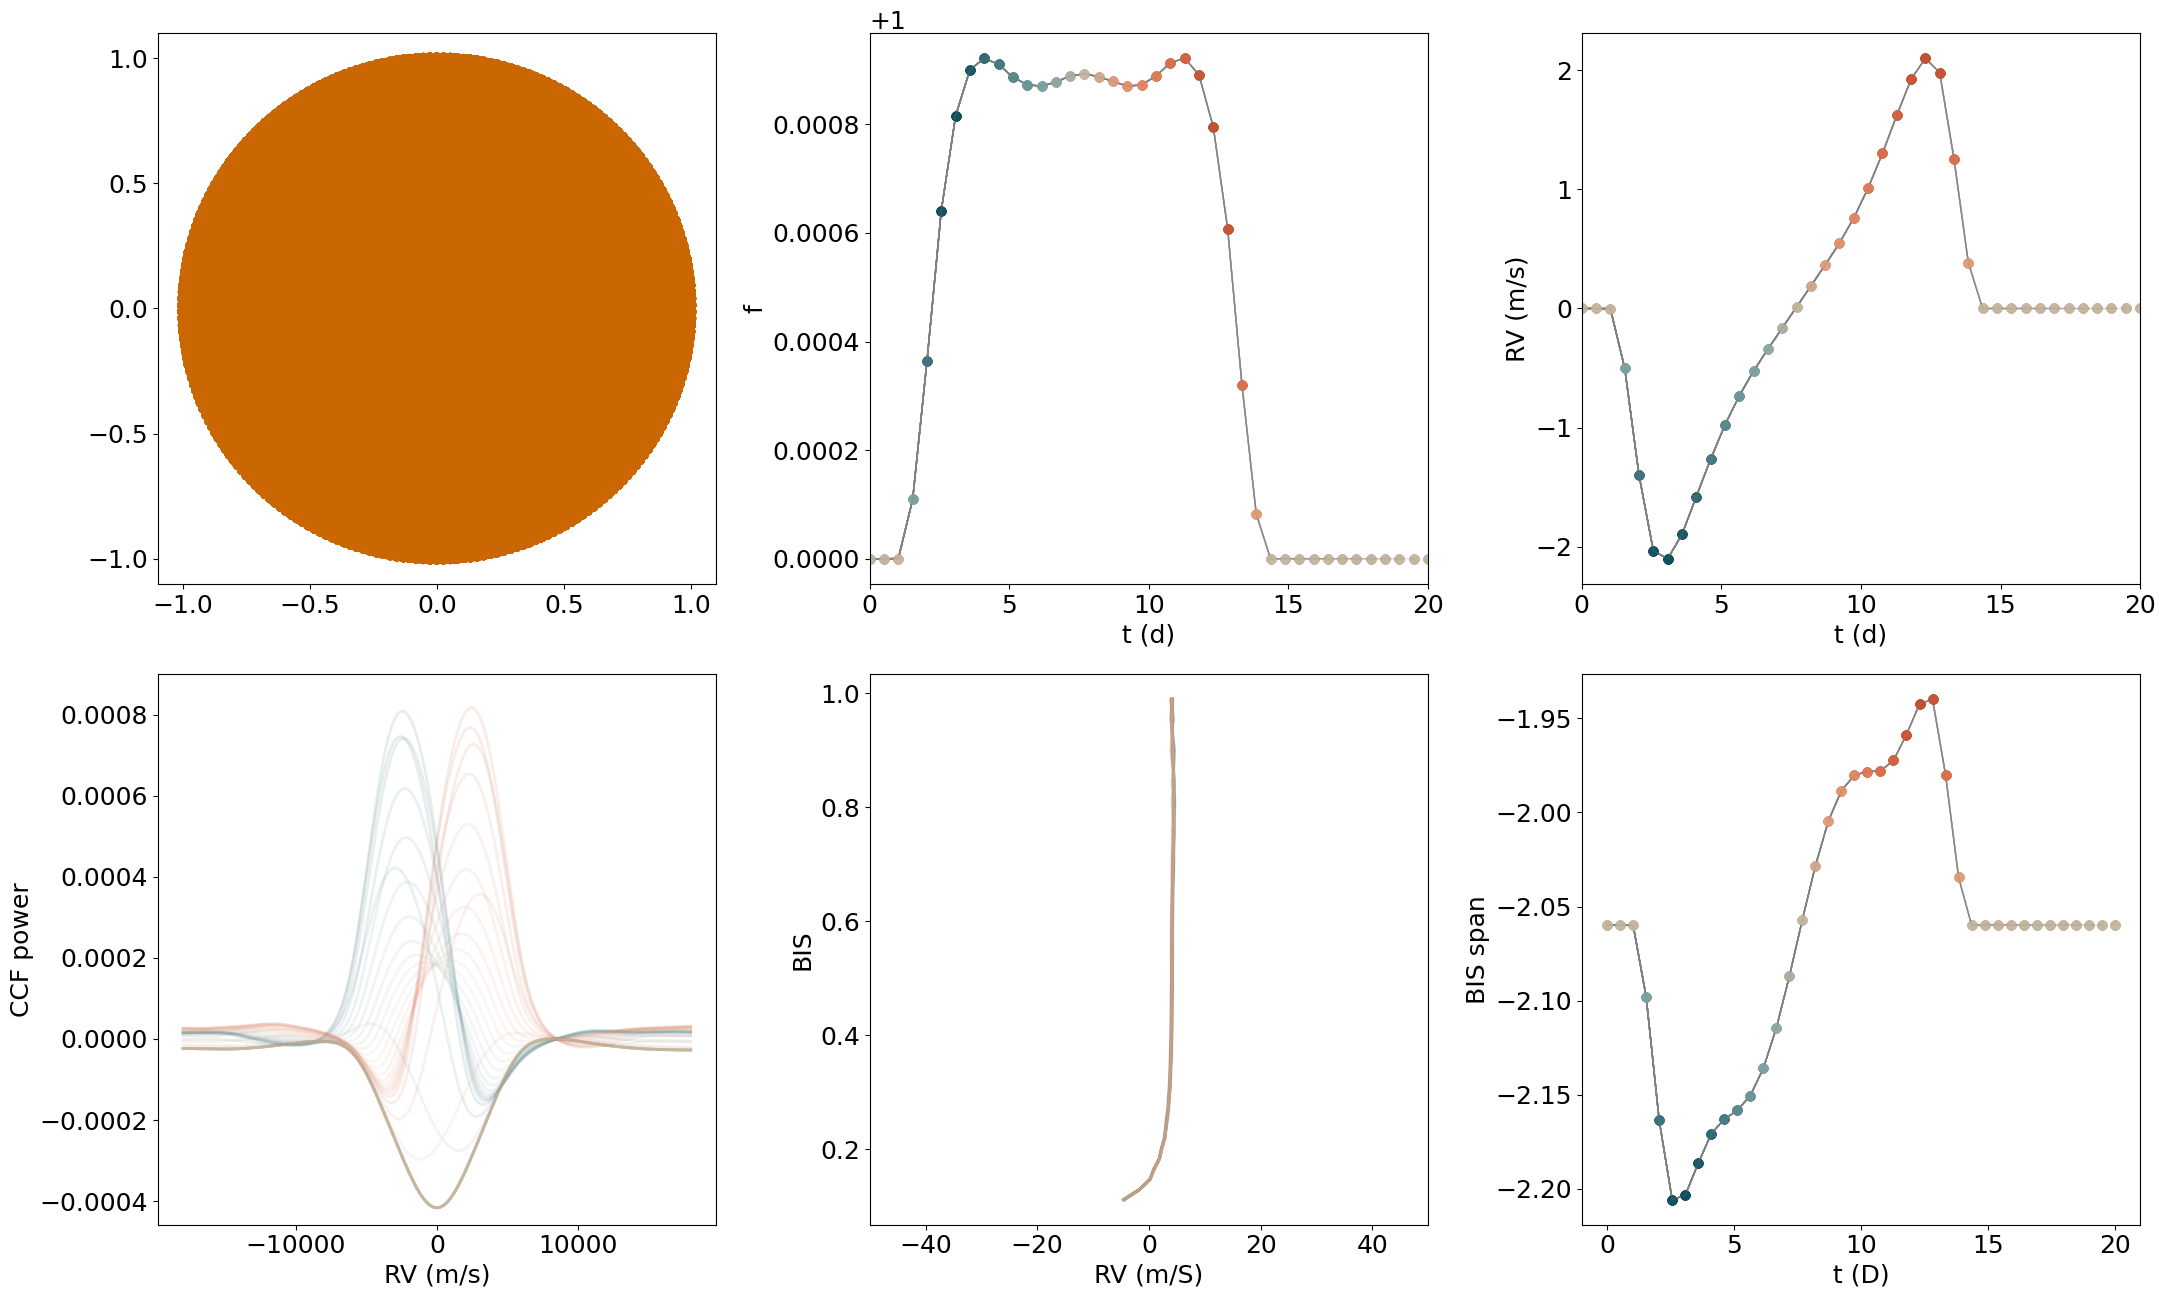

In [ ]:
output = 'fc_phoenix_{}'.format(spec_line)
retrieve_observable(ss_phoenix, t, pathdata, path_grid, output)

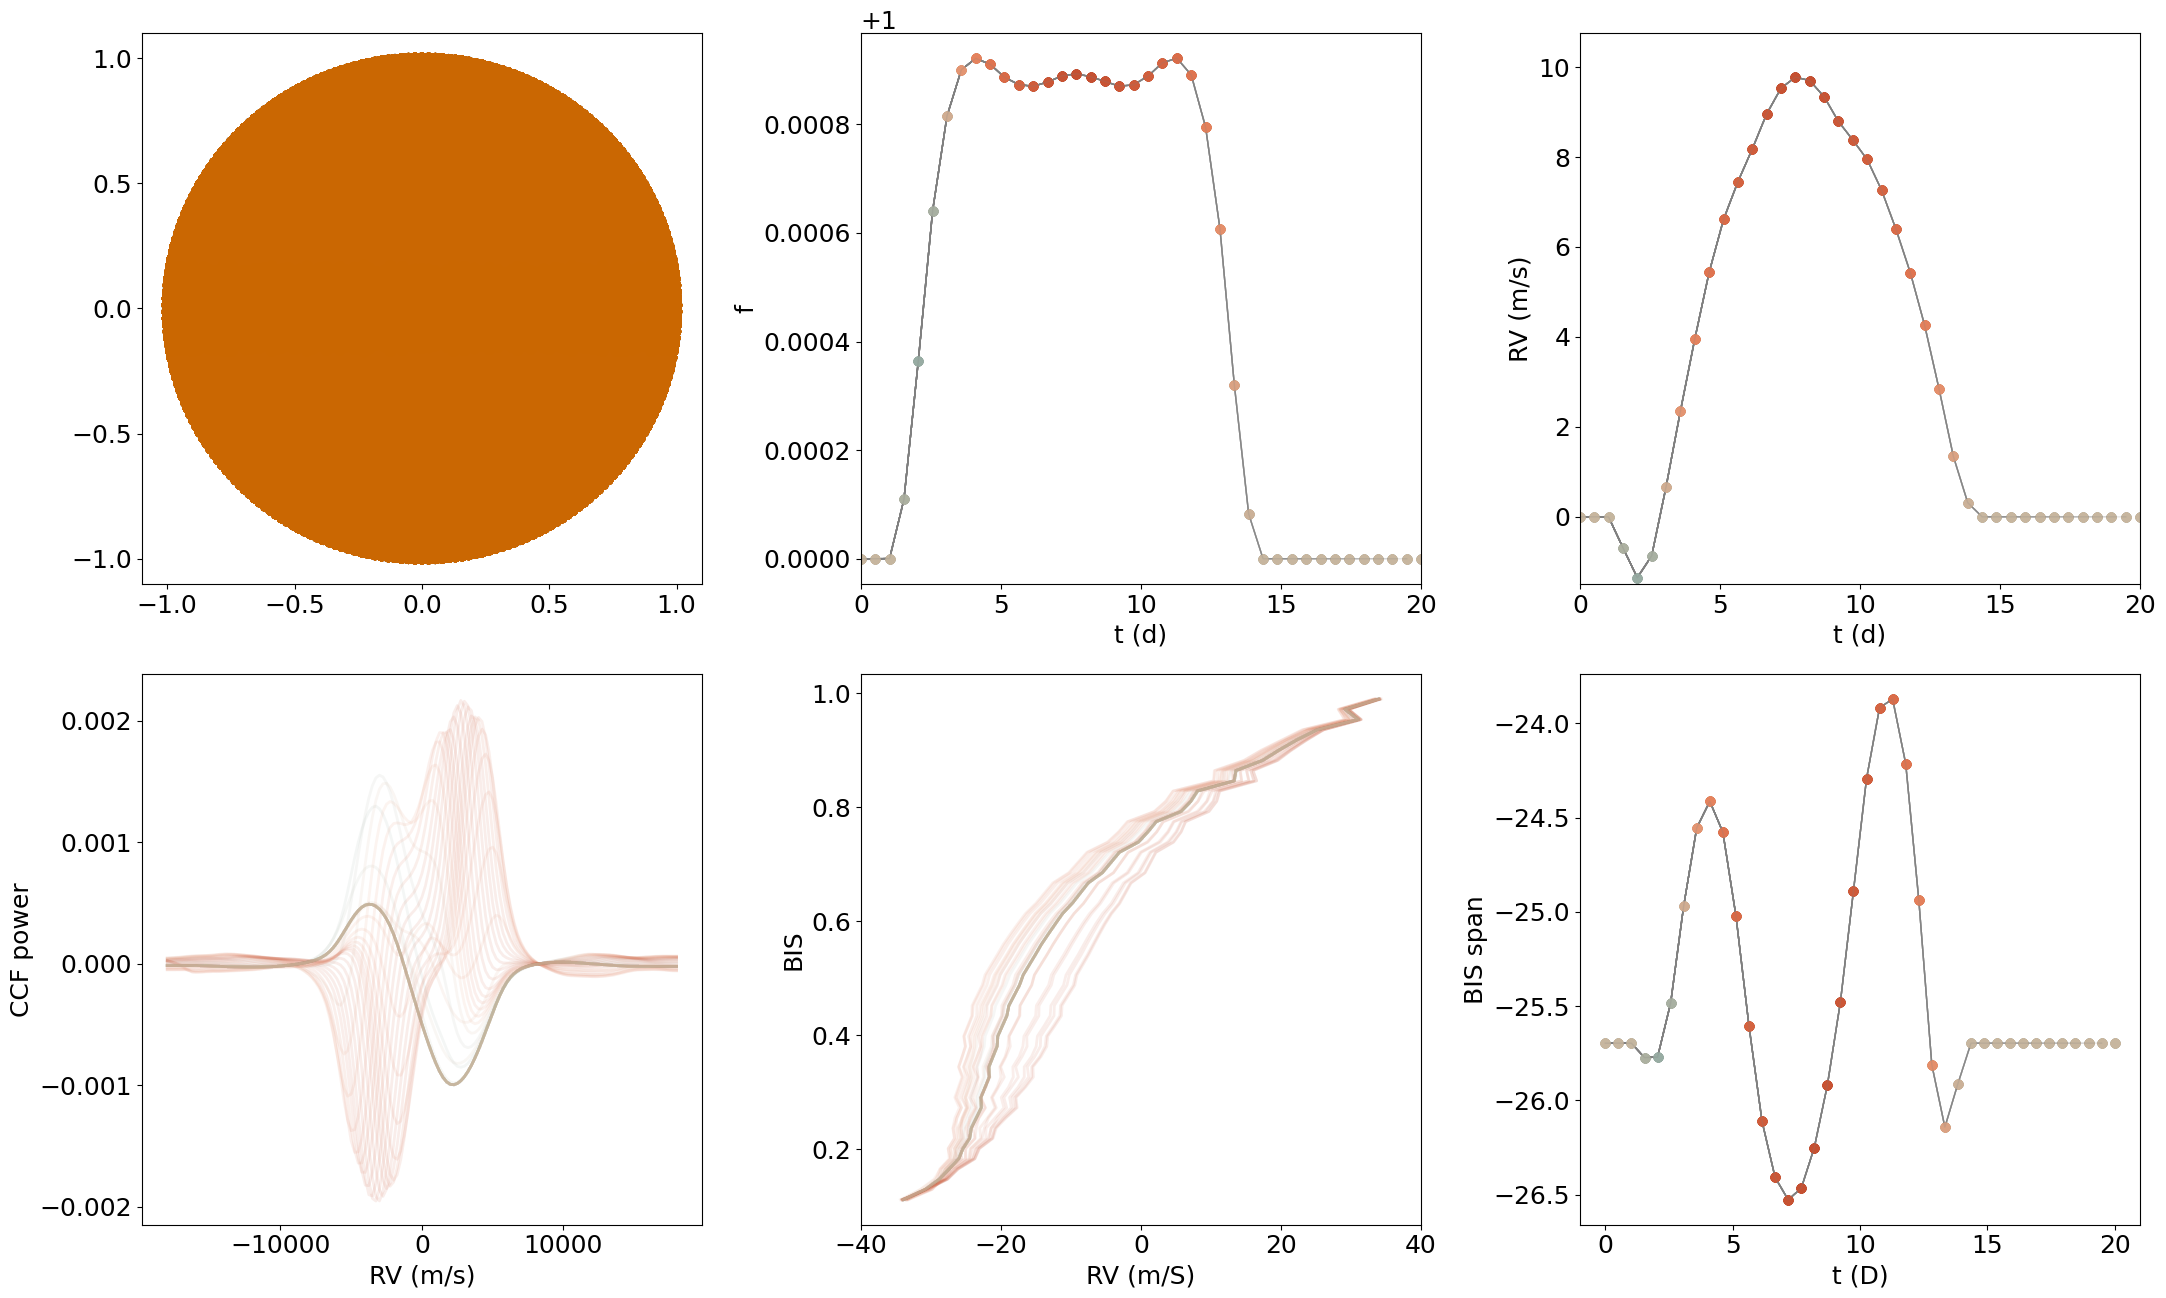

In [ ]:
output = 'fc_phoenix_blue_{}'.format(spec_line)
retrieve_observable(ss_phoenix_blue, t, pathdata, path_grid, output)